Found 1840 images belonging to 2 classes.
Found 460 images belonging to 2 classes.
Class indices: {'damaged': 0, 'non damaged': 1}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 14,974,977 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

C:\Users\EBIN BABU\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.6516 - loss: 0.6286 - val_accuracy: 0.8739 - val_loss: 0.3378
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.8196 - loss: 0.3986 - val_accuracy: 0.8978 - val_loss: 0.2481
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.8723 - loss: 0.3063 - val_accuracy: 0.9109 - val_loss: 0.2070
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 207s 4s/step - accuracy: 0.8935 - loss: 0.2668 - val_accuracy: 0.9174 - val_loss: 0.1825
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.9016 - loss: 0.2578 - val_accuracy: 0.9304 - val_loss: 0.1706
Epoch 6/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.9141 - loss: 0.2197 - val_accuracy: 0.9413 - val_loss: 0.1636
Epoch 7/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.9223 - loss: 0.2092 - val_accuracy: 0.9435 - val_loss: 0.1582
Epoch 8/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.9234 - loss: 0.1955 - val_accuracy: 0.9413 - v

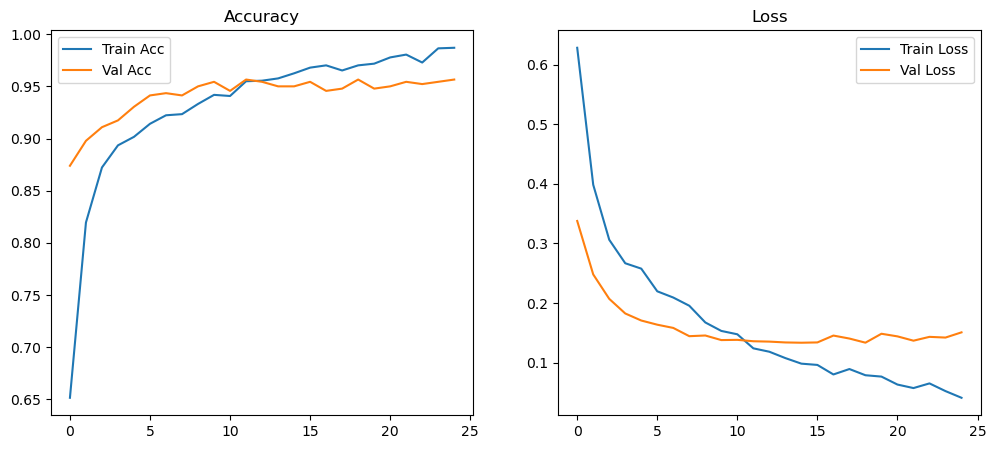

15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step  

Classification Report:
              precision    recall  f1-score   support

     damaged       0.96      0.95      0.96       230
 non damaged       0.95      0.97      0.96       230

    accuracy                           0.96       460
   macro avg       0.96      0.96      0.96       460
weighted avg       0.96      0.96      0.96       460



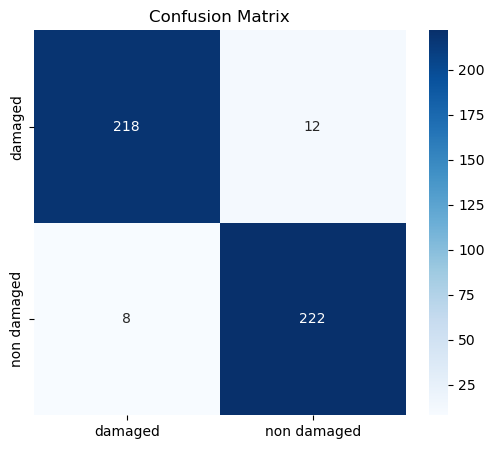

Model saved successfully!


In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# STEP 1 — Dataset Path
BASE = Path(r"C:\Users\EBIN BABU\Downloads\archive (10)\data")  # Update if needed

TRAIN_DIR = BASE / "training"
VAL_DIR = BASE / "validation"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# STEP 2 — Data Generators with ResNet50 preprocessing
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Using shuffle=True for training, shuffle=False for validation to keep label order correct
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False 
)

print("Class indices:", train_data.class_indices)

# STEP 3 — Build and Fine-tune ResNet50 Model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers except last 30 layers for fine tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# STEP 4 — Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

# STEP 5 — Evaluate Accuracy
loss, acc = model.evaluate(val_data)
print(f"\nValidation Accuracy: {acc * 100:.2f}%\n")

# STEP 6 — Plot Accuracy and Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.show()

# STEP 7 — Evaluation Metrics with correct label alignment
val_data.reset()  # Reset iterator to start
predictions_prob = model.predict(val_data, verbose=1)
predictions = (predictions_prob > 0.5).astype(int).flatten()  # Use 0.5 threshold (standard) or adjust carefully

true_labels = val_data.classes  # The labels are in order as shuffle=False

print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=list(train_data.class_indices.keys())))

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(train_data.class_indices.keys()),
            yticklabels=list(train_data.class_indices.keys()))
plt.title("Confusion Matrix")
plt.show()

# STEP 8 — Save Model
model.save("damaged_car_resnet50_finetuned.h5")
print("Model saved successfully!")



In [2]:
# class_indices: {'damaged': 0, 'non_damaged': 1}

def predict_image(img_path, threshold=0.5):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Model prediction
    prob = model.predict(img_array)[0][0]  # P(non_damaged)
    prob_percent = prob * 100

    if prob > threshold:
        predicted_label = "non_damaged"
    else:
        predicted_label = "damaged"

    print(f"\nProbability (non_damaged): {prob_percent:.2f}%")
    print(f"Predicted Label: {predicted_label}\n")

    plt.imshow(load_img(img_path))
    plt.axis("off")
    plt.title(f"{predicted_label} ({prob_percent:.2f}%)")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

Probability (non_damaged): 0.07%
Predicted Label: damaged



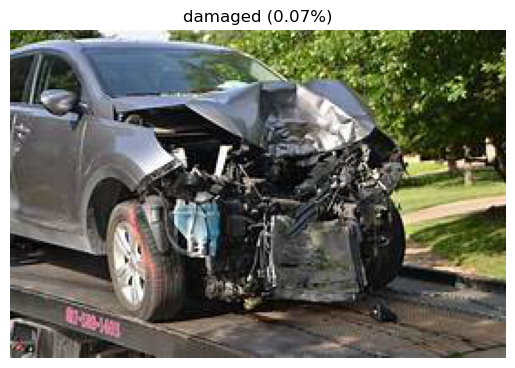

In [3]:
test_img = r"C:\Users\EBIN BABU\Downloads\OIP (15).jpg"
predict_image(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step

Probability (non_damaged): 100.00%
Predicted Label: non_damaged



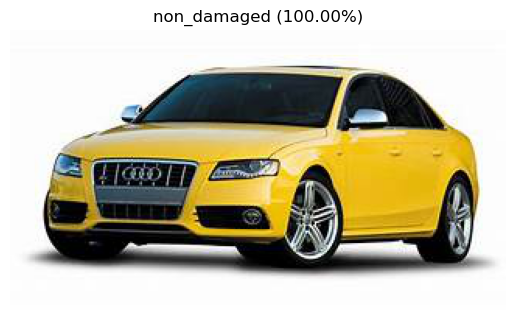

In [4]:
test_img = r"C:\Users\EBIN BABU\Downloads\OIP (5).jpg"
predict_image(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step

Probability (non_damaged): 0.65%
Predicted Label: damaged



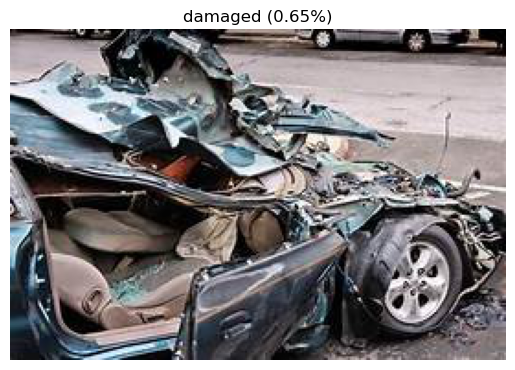

In [5]:
test_img = r"C:\Users\EBIN BABU\Downloads\OIP (14).jpg"
predict_image(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step

Probability (non_damaged): 100.00%
Predicted Label: non_damaged



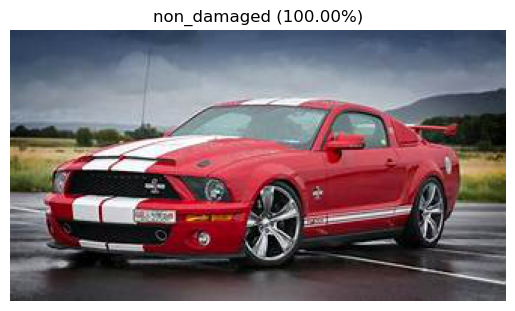

In [6]:
test_img = r"C:\Users\EBIN BABU\Downloads\OIP (8).jpg"
predict_image(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step

Probability (non_damaged): 0.94%
Predicted Label: damaged



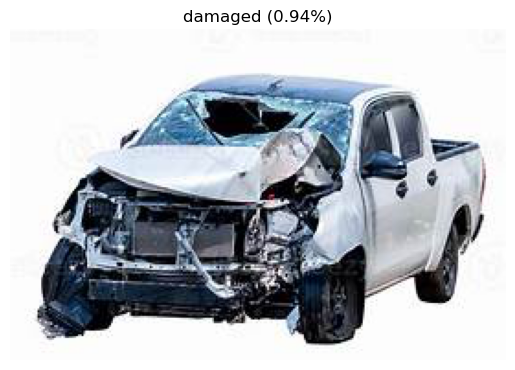

In [7]:
test_img = r"C:\Users\EBIN BABU\Downloads\OIP (13).jpg"
predict_image(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step

Probability (non_damaged): 99.99%
Predicted Label: non_damaged



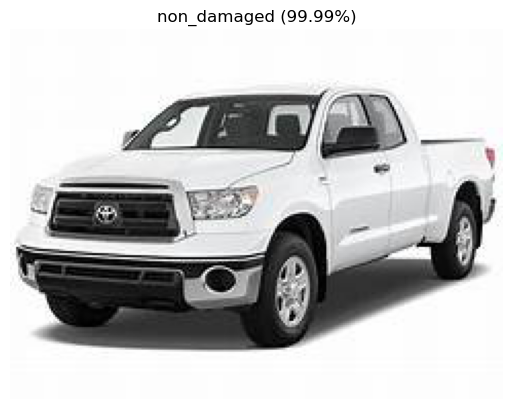

In [8]:
test_img = r"C:\Users\EBIN BABU\Downloads\OIP (9).jpg"
predict_image(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step

Probability (non_damaged): 0.18%
Predicted Label: damaged



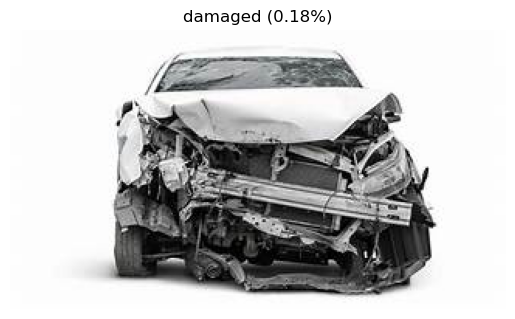

In [9]:
test_img = r"C:\Users\EBIN BABU\Downloads\OIP (10).jpg"
predict_image(test_img)